In [9]:
from pathlib import Path
import json
import math
import os
import shutil
import subprocess
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Video, display

%matplotlib inline


In [10]:
PROJECT_DIR = Path("cpp_reactive_euler_openmp_fullviz_new").resolve()
if not PROJECT_DIR.exists():
    alt = Path.cwd().resolve()
    if (alt / "src" / "main.cpp").exists() and (alt / "tools" / "postprocess.py").exists():
        PROJECT_DIR = alt

TOOLS_DIR = PROJECT_DIR / "tools"
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import postprocess as pv

print("PROJECT_DIR =", PROJECT_DIR)
print("TOOLS_DIR   =", TOOLS_DIR)


PROJECT_DIR = /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new
TOOLS_DIR   = /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/tools


In [11]:
XL = -50.0
XR = 300.0
YL = 0.0
YR = 40.0
DX_TARGET = 0.10
DY_TARGET = 0.10

NX = int(round((XR - XL) / DX_TARGET))
NY = int(round((YR - YL) / DY_TARGET))
DX_ACTUAL = (XR - XL) / NX
DY_ACTUAL = (YR - YL) / NY

FINAL_TIME = 30.0
CFL = 0.20
REACT_CFL = 0.20
TRACK_DT = 0.25
SAVE_DT = 0.50
P_IGN = 70.0

THREADS = min(32, os.cpu_count() or 1)
CASE_TAG = f"openmp_python_style_x-50_180_y0_24_dx{DX_ACTUAL:.2f}_t{FINAL_TIME:g}_thr{THREADS}"
OUTPUT_ROOT = (PROJECT_DIR / "runs" / CASE_TAG).resolve()
SNAPSHOT_BIN_DIR = OUTPUT_ROOT / "snapshots"
SNAPSHOT_NPZ_DIR = OUTPUT_ROOT / "snapshots_npz"
FRAME_ROOT = OUTPUT_ROOT / "frames_fixed_lab_pairs"
VIDEO_DIR = OUTPUT_ROOT / "videos_fixed_lab_pairs"
STATIC_DIR = OUTPUT_ROOT / "static_plots"

par = pv.Params(gamma=1.4, Q=20.0, k=1.0, Ea=20.0, R=1.0)

print(f"Nx, Ny      = {NX}, {NY}")
print(f"dx, dy      = {DX_ACTUAL:.8f}, {DY_ACTUAL:.8f}")
print(f"final_time  = {FINAL_TIME}")
print(f"threads     = {THREADS}")
print(f"output root = {OUTPUT_ROOT}")


Nx, Ny      = 3500, 400
dx, dy      = 0.10000000, 0.10000000
final_time  = 30.0
threads     = 32
output root = /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32


In [12]:
def run_command(cmd, cwd=None, env=None, check=True):
    print("$", " ".join(map(str, cmd)))
    t0 = time.perf_counter()
    proc = subprocess.run(cmd, cwd=cwd, env=env, text=True, capture_output=True)
    wall = time.perf_counter() - t0
    if proc.stdout:
        print(proc.stdout)
    if proc.stderr:
        print(proc.stderr)
    if check and proc.returncode != 0:
        raise RuntimeError(f"Command failed with return code {proc.returncode}: {' '.join(map(str, cmd))}")
    return proc, wall

COMPILE_CLEAN = False
if COMPILE_CLEAN:
    run_command(["make", "clean"], cwd=PROJECT_DIR, check=False)

compile_proc, compile_wall = run_command(["make"], cwd=PROJECT_DIR)
EXECUTABLE = PROJECT_DIR / "reactive_euler_2d_openmp"
assert EXECUTABLE.exists(), f"Executable not found: {EXECUTABLE}"
print("compile wall time [s] =", compile_wall)


$ make
g++ -O3 -std=c++17 -Wall -Wextra -pedantic -fopenmp src/main.cpp -o reactive_euler_2d_openmp

compile wall time [s] = 1.1633003279566765


In [13]:
RUN_FULL_SOLVER = True
OVERWRITE_OUTPUT = True

if RUN_FULL_SOLVER:
    if OUTPUT_ROOT.exists() and OVERWRITE_OUTPUT:
        shutil.rmtree(OUTPUT_ROOT)
    OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

    cmd = [
        str(EXECUTABLE),
        "--nx", str(NX), "--ny", str(NY),
        "--xL", str(XL), "--xR", str(XR), "--yL", str(YL), "--yR", str(YR),
        "--final", str(FINAL_TIME),
        "--cfl", str(CFL),
        "--react-cfl", str(REACT_CFL),
        "--save-dt", str(SAVE_DT),
        "--track-dt", str(TRACK_DT),
        "--pign", str(P_IGN),
        "--threads", str(THREADS),
        "--out", str(OUTPUT_ROOT),
    ]

    print("Launching C++/OpenMP solver...")
    t0 = time.perf_counter()
    proc = subprocess.Popen(cmd, cwd=PROJECT_DIR, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, bufsize=1)
    solver_lines = []
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
        solver_lines.append(line)
    return_code = proc.wait()
    solver_wall = time.perf_counter() - t0
    if return_code != 0:
        raise RuntimeError(f"C++ solver failed with return code {return_code}")

    summary = {
        "command": cmd,
        "return_code": return_code,
        "compile_wall_time_s": compile_wall,
        "python_measured_solver_wall_time_s": solver_wall,
        "project_dir": str(PROJECT_DIR),
        "output_root": str(OUTPUT_ROOT),
        "Nx": NX, "Ny": NY, "cells": NX * NY,
        "xL": XL, "xR": XR, "yL": YL, "yR": YR,
        "dx": DX_ACTUAL, "dy": DY_ACTUAL,
        "final_time": FINAL_TIME,
        "save_dt": SAVE_DT,
        "track_dt": TRACK_DT,
        "cfl": CFL,
        "react_cfl": REACT_CFL,
        "p_ign": P_IGN,
        "threads": THREADS,
    }
    with (OUTPUT_ROOT / "run_summary.json").open("w") as f:
        json.dump(summary, f, indent=2)
    with (OUTPUT_ROOT / "solver_stdout.txt").open("w") as f:
        f.write("".join(solver_lines))

    print("\nPython-measured solver wall time [s] =", solver_wall)
else:
    print("RUN_FULL_SOLVER=False, using existing output at", OUTPUT_ROOT)


Launching C++/OpenMP solver...
2D reactive Euler 
Nx, Ny      = 3500, 400
domain x    = [-50, 300]
domain y    = [0, 40]
final_time  = 30
OpenMP      = enabled, threads=32
scheme      = HLLC + MUSCL/MC + SSP-RK3 + Strang reaction
step=     20 t=  0.036589 dt=1.828959e-03 pmax=82.2845 shock_x=2.1015
step=     40 t=  0.072358 dt=1.738948e-03 pmax=80.9137 shock_x=2.1190
step=     60 t=  0.106129 dt=1.646888e-03 pmax=79.4302 shock_x=2.1455
step=     80 t=  0.138326 dt=1.579959e-03 pmax=78.1960 shock_x=2.1768
step=    100 t=  0.169386 dt=1.531162e-03 pmax=77.2820 shock_x=2.2143
step=    120 t=  0.199604 dt=1.494390e-03 pmax=76.5979 shock_x=2.2540
step=    140 t=  0.229181 dt=1.465928e-03 pmax=76.0447 shock_x=2.2978
step=    160 t=  0.257231 dt=1.444181e-03 pmax=75.5947 shock_x=2.3515
step=    180 t=  0.285919 dt=1.426048e-03 pmax=75.1880 shock_x=2.4110
step=    200 t=  0.314278 dt=1.411201e-03 pmax=74.8332 shock_x=2.4743
step=    220 t=  0.342370 dt=1.398878e-03 pmax=74.5254 shock_x=2.6075


In [14]:
CONVERT_SNAPSHOTS = True

if CONVERT_SNAPSHOTS:
    t0 = time.perf_counter()
    manifest = pv.convert_cpp_binary_snapshots_to_npz(
        SNAPSHOT_BIN_DIR,
        SNAPSHOT_NPZ_DIR,
        par,
        dtype=np.float32,
        overwrite=True,
    )
    convert_wall = time.perf_counter() - t0
    print(f"Converted {len(manifest)} snapshots to {SNAPSHOT_NPZ_DIR}")
    print(f"conversion wall time [s] = {convert_wall:.3f}")
else:
    manifest = [{"file": str(f), "t": pv.load_disk_snapshot(f)["t"]} for f in pv.list_disk_snapshots(SNAPSHOT_NPZ_DIR)]
    convert_wall = None

snapshot_files = pv.list_disk_snapshots(SNAPSHOT_NPZ_DIR)
print("NPZ snapshots:", len(snapshot_files))
print("first:", snapshot_files[0] if snapshot_files else None)
print("last: ", snapshot_files[-1] if snapshot_files else None)


Converted 62 snapshots to /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/snapshots_npz
conversion wall time [s] = 6.680
NPZ snapshots: 62
first: /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/snapshots_npz/snapshot_00000.npz
last:  /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/snapshots_npz/snapshot_00061.npz


,step,t,dt,p_max,lam_max,shock_x_mean
0,0,0.00,0.000000,82.884189,0.000000,2.09700
1,155,0.25,0.000420,75.706256,0.177105,2.33775
2,335,0.50,0.000845,73.380509,0.318965,3.61800
3,522,0.75,0.000124,77.336347,0.433633,5.27475
4,710,1.00,0.000560,83.094165,0.529273,6.92800


,step,t,dt,p_max,lam_max,shock_x_mean
116,20762,29.00,0.001257,25.239737,1.0,167.58650
117,20929,29.25,0.000906,25.022247,1.0,168.85350
118,21097,29.50,0.000836,25.168336,1.0,170.12000
119,21266,29.75,0.000311,25.314009,1.0,171.39000
120,21435,30.00,0.000244,25.593987,1.0,172.65925


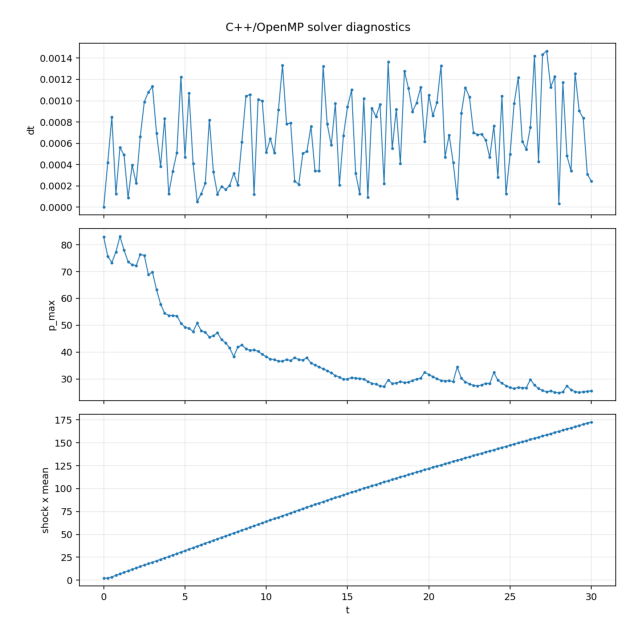

In [15]:
DIAG_PATH = OUTPUT_ROOT / "diagnostics.csv"
diag = pd.read_csv(DIAG_PATH)
display(diag.head())
display(diag.tail())

pv.plot_diagnostics_csv(diag, STATIC_DIR)
img = plt.imread(STATIC_DIR / "diagnostics_dt_pmax_shock.png")
plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off");


In [16]:
final_snapshot = snapshot_files[-1]
trajectory = pv.trajectory_from_npz_snapshots(SNAPSHOT_NPZ_DIR, par, p_level=2.0, lambda_level=0.5)
front_plot, front_stats = pv.plot_front_trajectory(trajectory, STATIC_DIR, D_cj=6.415008470922, t_fit_min=4.0)
print(front_stats)


last = pv.load_disk_snapshot(final_snapshot)
rho, u, v, p, T, lam = pv.primitive_fields_from_U(last["U"], par)
x_shock_y = pv.front_positions_by_level_lab(last["x"], p, 2.0)
shock_mean = np.nanmean(x_shock_y)
field_xlim = (max(XL, shock_mean - 110.0), min(XR, shock_mean + 20.0)) if np.isfinite(shock_mean) else (XL, XR)
print("field_xlim =", field_xlim)

pv.plot_final_fields(final_snapshot, par, STATIC_DIR, xlim=field_xlim)
pv.plot_schlieren_and_sootfoil(final_snapshot, par, STATIC_DIR, xlim=field_xlim)
pv.plot_front_kymographs(SNAPSHOT_NPZ_DIR, par, STATIC_DIR, p_level=2.0, lambda_level=0.5)
pv.plot_reaction_zone_thickness(SNAPSHOT_NPZ_DIR, par, STATIC_DIR, p_level=2.0, lambda_level=0.5)
pv.plot_vorticity_field(final_snapshot, par, STATIC_DIR, xlim=field_xlim)

for name in [
    "front_trajectory.png",
    "final_2d_fields.png",
    "schlieren_and_sootfoil_contrast.png",
    "front_kymographs.png",
    "reaction_zone_thickness.png",
    "vorticity_final.png",
]:
    path = STATIC_DIR / name
    if path.exists():
        print(path)


{'D_shock': 5.603010823841198, 'D_lambda': 4.781362606021245, 'shock_rms': 2.1466107876271536, 'lambda_rms': 0.927318843119011}
field_xlim = (np.float64(62.659250717163076), np.float64(192.65925071716308))
/home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/static_plots/front_trajectory.png
/home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/static_plots/final_2d_fields.png
/home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/static_plots/schlieren_and_sootfoil_contrast.png
/home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/static_plots/front_kymographs.png
/home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/static_plots/reaction_zone_thickness.pn

In [17]:
RENDER_FRAMES = True
RECENT_MAX_WINDOW = 1.5
ANIMATION_DPI = 120

if RENDER_FRAMES:
    t0 = time.perf_counter()
    rendered_frames, animation_limits = pv.render_fixed_lab_pair_animation_frames(
        snapshot_dir=SNAPSHOT_NPZ_DIR,
        par=par,
        frame_root=FRAME_ROOT,
        fixed_xlim=None,     
        recent_window=RECENT_MAX_WINDOW,
        dpi=ANIMATION_DPI,
        clean=True,
        scan_all_for_limits=True,
    )
    render_wall = time.perf_counter() - t0
    print(f"frame rendering wall time [s] = {render_wall:.3f}")
else:
    rendered_frames = None
    animation_limits = None
    render_wall = None


Computing stable color/y limits...
Rendering fixed-lab pair frames from 62 snapshots...
Frame root: /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/frames_fixed_lab_pairs
Fixed xlim: full domain
Recent-max window: 1.5
  rendered 10/62
  rendered 20/62
  rendered 30/62
  rendered 40/62
  rendered 50/62
  rendered 60/62
  rendered 62/62
frame rendering wall time [s] = 270.482


In [18]:
BUILD_VIDEOS = True
ANIMATION_FPS = 20

if BUILD_VIDEOS:
    t0 = time.perf_counter()
    videos = pv.build_fixed_lab_pair_videos_from_frames(
        frame_root=FRAME_ROOT,
        video_dir=VIDEO_DIR,
        fps=ANIMATION_FPS,
    )
    video_wall = time.perf_counter() - t0
    print(f"video encoding wall time [s] = {video_wall:.3f}")
else:
    videos = {}
    video_wall = None

print("Video directory:", VIDEO_DIR)
for k, v in videos.items():
    print(f"{k:36s}: {v}")


Saved video: /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/yavg_profiles_fixed_lab.mp4
Saved video: /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/fields_p_rho_fixed_lab.mp4
Saved video: /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/fields_u_v_fixed_lab.mp4
Saved video: /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/fields_T_lambda_fixed_lab.mp4
Saved video: /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/cellular_accum_pmax_contrast_fixed_lab.mp4
Saved video: /home/nikita/jupyter/HPC/cpp_reactive_euler_openm

In [19]:
for key in [
    "yavg_profiles",
    "fields_p_rho",
    "fields_u_v",
    "fields_T_lambda",
    "cellular_accum_pmax_contrast",
    "cellular_accum_Tmax_schlieren",
    "cellular_recent_pmax_contrast",
    "vorticity",
]:
    vpath = videos.get(key)
    if vpath and Path(vpath).exists():
        print("\n", key, "->", vpath)
        display(Video(vpath, embed=False, html_attributes="controls width=900"))



 yavg_profiles -> /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/yavg_profiles_fixed_lab.mp4



 fields_p_rho -> /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/fields_p_rho_fixed_lab.mp4



 fields_u_v -> /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/fields_u_v_fixed_lab.mp4



 fields_T_lambda -> /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/fields_T_lambda_fixed_lab.mp4



 cellular_accum_pmax_contrast -> /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/cellular_accum_pmax_contrast_fixed_lab.mp4



 cellular_accum_Tmax_schlieren -> /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/cellular_accum_Tmax_schlieren_fixed_lab.mp4



 cellular_recent_pmax_contrast -> /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/cellular_recent_pmax_contrast_fixed_lab.mp4



 vorticity -> /home/nikita/jupyter/HPC/cpp_reactive_euler_openmp_fullviz _new/runs/openmp_python_style_x-50_180_y0_24_dx0.10_t30_thr32/videos_fixed_lab_pairs/vorticity_fixed_lab.mp4


In [ ]:
report = {
    "project_dir": str(PROJECT_DIR),
    "output_root": str(OUTPUT_ROOT),
    "snapshot_bin_dir": str(SNAPSHOT_BIN_DIR),
    "snapshot_npz_dir": str(SNAPSHOT_NPZ_DIR),
    "frame_root": str(FRAME_ROOT),
    "video_dir": str(VIDEO_DIR),
    "static_dir": str(STATIC_DIR),
    "Nx": NX,
    "Ny": NY,
    "cells": NX * NY,
    "domain": {"xL": XL, "xR": XR, "yL": YL, "yR": YR},
    "dx": DX_ACTUAL,
    "dy": DY_ACTUAL,
    "final_time": FINAL_TIME,
    "save_dt": SAVE_DT,
    "track_dt": TRACK_DT,
    "threads": THREADS,
    "compile_wall_time_s": compile_wall,
    "convert_wall_time_s": convert_wall,
    "render_wall_time_s": render_wall,
    "video_wall_time_s": video_wall,
    "front_stats": front_stats,
    "videos": videos,
}

# Merge with solver wall time if available.
summary_path = OUTPUT_ROOT / "run_summary.json"
if summary_path.exists():
    with summary_path.open() as f:
        solver_summary = json.load(f)
    report.update({k: solver_summary[k] for k in ["python_measured_solver_wall_time_s"] if k in solver_summary})

out_report = OUTPUT_ROOT / "python_postprocess_report.json"
with out_report.open("w") as f:
    json.dump(report, f, indent=2)

print("Saved report:", out_report)
report


In [ ]:

import re

RUN_SPEED_SWEEP = True


SWEEP_THREADS = [1, 2, 4, 8, 16, 32]


SWEEP_XL = XL
SWEEP_XR = XR
SWEEP_YL = YL
SWEEP_YR = YR
SWEEP_DX_TARGET = 0.30
SWEEP_DY_TARGET = 0.30
SWEEP_NX = int(round((SWEEP_XR - SWEEP_XL) / SWEEP_DX_TARGET))
SWEEP_NY = int(round((SWEEP_YR - SWEEP_YL) / SWEEP_DY_TARGET))
SWEEP_DX_ACTUAL = (SWEEP_XR - SWEEP_XL) / SWEEP_NX
SWEEP_DY_ACTUAL = (SWEEP_YR - SWEEP_YL) / SWEEP_NY

SWEEP_FINAL_TIME = 30.0


SWEEP_SAVE_DT = SWEEP_FINAL_TIME + 1.0
SWEEP_TRACK_DT = max(TRACK_DT, 0.25)

SPEED_ROOT = PROJECT_DIR / "runs" / (
    f"speed_sweep_x-50_180_y0_24_dx{SWEEP_DX_ACTUAL:.2f}_t{SWEEP_FINAL_TIME:g}"
)
SPEED_PLOTS_DIR = SPEED_ROOT / "plots"
SPEED_PLOTS_DIR.mkdir(parents=True, exist_ok=True)

def run_openmp_speed_case(nthreads, overwrite=True):
    """Run one C++/OpenMP timing case and return a result dictionary."""
    case_dir = SPEED_ROOT / f"thr{nthreads:02d}"
    if case_dir.exists() and overwrite:
        shutil.rmtree(case_dir)
    case_dir.mkdir(parents=True, exist_ok=True)

    cmd = [
        str(EXECUTABLE),
        "--nx", str(SWEEP_NX), "--ny", str(SWEEP_NY),
        "--xL", str(SWEEP_XL), "--xR", str(SWEEP_XR),
        "--yL", str(SWEEP_YL), "--yR", str(SWEEP_YR),
        "--final", str(SWEEP_FINAL_TIME),
        "--cfl", str(CFL),
        "--react-cfl", str(REACT_CFL),
        "--save-dt", str(SWEEP_SAVE_DT),
        "--track-dt", str(SWEEP_TRACK_DT),
        "--pign", str(P_IGN),
        "--threads", str(nthreads),
        "--out", str(case_dir),
    ]

    env = os.environ.copy()
    env["OMP_NUM_THREADS"] = str(nthreads)
    env["OMP_PROC_BIND"] = env.get("OMP_PROC_BIND", "spread")
    env["OMP_PLACES"] = env.get("OMP_PLACES", "cores")

    print("\n" + "=" * 90)
    print(f"OpenMP speed case: {nthreads} thread(s)")
    print("$", " ".join(map(str, cmd)))

    t0 = time.perf_counter()
    proc = subprocess.Popen(
        cmd,
        cwd=PROJECT_DIR,
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        bufsize=1,
    )

    solver_lines = []
    assert proc.stdout is not None
    for line in proc.stdout:
        print(line, end="")
        solver_lines.append(line)
    return_code = proc.wait()
    wall = time.perf_counter() - t0

    if return_code != 0:
        raise RuntimeError(f"Speed case failed for {nthreads} thread(s), return code {return_code}")

    stdout_text = "".join(solver_lines)
    (case_dir / "solver_stdout.txt").write_text(stdout_text)

    diag_path = case_dir / "diagnostics.csv"
    final_step = np.nan
    final_t = np.nan
    if diag_path.exists():
        d = pd.read_csv(diag_path)
        if len(d) > 0:
            final_step = int(d["step"].iloc[-1])
            final_t = float(d["t"].iloc[-1])

    cells = SWEEP_NX * SWEEP_NY
    mcell_steps_s = (cells * final_step) / wall / 1.0e6 if final_step and final_step > 0 else np.nan

    timing = {}
    patterns = {
        "compute_dt_s": r"compute_dt\s*[:=]\s*([0-9.eE+-]+)",
        "reaction_s": r"reaction\s*[:=]\s*([0-9.eE+-]+)",
        "rhs_s": r"(?:HLLC/MUSCL RHS|rhs)\s*[:=]\s*([0-9.eE+-]+)",
        "rk_updates_s": r"(?:RK vector updates|rk)\s*[:=]\s*([0-9.eE+-]+)",
        "bc_s": r"(?:sanitize \+ BC|bc)\s*[:=]\s*([0-9.eE+-]+)",
        "extrema_s": r"(?:p/T extrema hist|extrema)\s*[:=]\s*([0-9.eE+-]+)",
        "snapshot_io_s": r"(?:snapshot I/O|snapshot_io)\s*[:=]\s*([0-9.eE+-]+)",
        "timed_core_total_s": r"(?:timed core total|core total)\s*[:=]\s*([0-9.eE+-]+)",
        "cpp_reported_mcell_steps_s": r"(?:nominal MCell-step/s|MCell-step/s)\s*[:=]\s*([0-9.eE+-]+)",
    }
    for name, pat in patterns.items():
        m = re.search(pat, stdout_text, flags=re.IGNORECASE)
        if m:
            try:
                timing[name] = float(m.group(1))
            except ValueError:
                pass

    result = {
        "threads": int(nthreads),
        "wall_time_s": float(wall),
        "final_step": int(final_step) if not pd.isna(final_step) else None,
        "final_t": float(final_t) if not pd.isna(final_t) else None,
        "cells": int(cells),
        "Nx": int(SWEEP_NX),
        "Ny": int(SWEEP_NY),
        "dx": float(SWEEP_DX_ACTUAL),
        "dy": float(SWEEP_DY_ACTUAL),
        "final_time_target": float(SWEEP_FINAL_TIME),
        "million_cell_steps_per_s_python_wall": float(mcell_steps_s),
        "output_dir": str(case_dir),
        **timing,
    }

    with (case_dir / "speed_result.json").open("w") as f:
        json.dump(result, f, indent=2)

    print(f"\nPython-measured wall time [s] = {wall:.3f}")
    print(f"Nominal throughput [MCell-step/s] = {mcell_steps_s:.3f}")
    return result

def plot_speed_sweep_results(results_df, out_dir):
    """Create speedup, efficiency, wall-time, and throughput plots."""
    out_dir.mkdir(parents=True, exist_ok=True)
    df = results_df.sort_values("threads").copy()

    
    base_row = df[df["threads"] == 1]
    if len(base_row) == 0:
        base_row = df.iloc[[0]]
    base_threads = int(base_row["threads"].iloc[0])
    base_time = float(base_row["wall_time_s"].iloc[0])

    df["speedup_vs_baseline"] = base_time / df["wall_time_s"]
    df["ideal_speedup_vs_baseline"] = df["threads"] / base_threads
    df["parallel_efficiency"] = df["speedup_vs_baseline"] / df["ideal_speedup_vs_baseline"]

    csv_path = out_dir / "openmp_speed_sweep_results.csv"
    df.to_csv(csv_path, index=False)

    
    plt.figure(figsize=(7.5, 5))
    plt.plot(df["threads"], df["wall_time_s"], marker="o")
    plt.xscale("log", base=2)
    plt.xticks(df["threads"], [str(t) for t in df["threads"]])
    plt.xlabel("OpenMP threads")
    plt.ylabel("Wall time, s")
    plt.title("C++/OpenMP solver wall time")
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "openmp_wall_time.png", dpi=180)
    plt.show()


    plt.figure(figsize=(7.5, 5))
    plt.plot(df["threads"], df["speedup_vs_baseline"], marker="o", label="measured")
    plt.plot(df["threads"], df["ideal_speedup_vs_baseline"], linestyle="--", label="ideal")
    plt.xscale("log", base=2)
    plt.xticks(df["threads"], [str(t) for t in df["threads"]])
    plt.xlabel("OpenMP threads")
    plt.ylabel(f"Speedup vs {base_threads} thread(s)")
    plt.title("OpenMP speedup")
    plt.grid(True, which="both", alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / "openmp_speedup.png", dpi=180)
    plt.show()


    plt.figure(figsize=(7.5, 5))
    plt.plot(df["threads"], df["parallel_efficiency"], marker="o")
    plt.xscale("log", base=2)
    plt.xticks(df["threads"], [str(t) for t in df["threads"]])
    plt.xlabel("OpenMP threads")
    plt.ylabel("Parallel efficiency")
    plt.title("OpenMP parallel efficiency")
    plt.ylim(0, max(1.05, float(df["parallel_efficiency"].max()) * 1.1))
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "openmp_parallel_efficiency.png", dpi=180)
    plt.show()


    plt.figure(figsize=(7.5, 5))
    plt.plot(df["threads"], df["million_cell_steps_per_s_python_wall"], marker="o")
    plt.xscale("log", base=2)
    plt.xticks(df["threads"], [str(t) for t in df["threads"]])
    plt.xlabel("OpenMP threads")
    plt.ylabel("Million cell-steps / s")
    plt.title("OpenMP throughput")
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig(out_dir / "openmp_throughput.png", dpi=180)
    plt.show()

    return df, csv_path

if RUN_SPEED_SWEEP:
    print("Speed sweep grid:")
    print(f"  Nx, Ny       = {SWEEP_NX}, {SWEEP_NY}")
    print(f"  dx, dy       = {SWEEP_DX_ACTUAL:.8f}, {SWEEP_DY_ACTUAL:.8f}")
    print(f"  final_time   = {SWEEP_FINAL_TIME}")
    print(f"  save_dt      = {SWEEP_SAVE_DT}")
    print(f"  threads      = {SWEEP_THREADS}")
    print(f"  output root  = {SPEED_ROOT}")

    results = []
    for nth in SWEEP_THREADS:
        results.append(run_openmp_speed_case(nth, overwrite=True))

    speed_df = pd.DataFrame(results)
    display(speed_df)

    speed_df, speed_csv = plot_speed_sweep_results(speed_df, SPEED_PLOTS_DIR)
    display(speed_df)

    summary = {
        "speed_root": str(SPEED_ROOT),
        "plots_dir": str(SPEED_PLOTS_DIR),
        "results_csv": str(speed_csv),
        "threads": SWEEP_THREADS,
        "Nx": SWEEP_NX,
        "Ny": SWEEP_NY,
        "cells": SWEEP_NX * SWEEP_NY,
        "domain": {"xL": SWEEP_XL, "xR": SWEEP_XR, "yL": SWEEP_YL, "yR": SWEEP_YR},
        "dx": SWEEP_DX_ACTUAL,
        "dy": SWEEP_DY_ACTUAL,
        "final_time": SWEEP_FINAL_TIME,
        "save_dt": SWEEP_SAVE_DT,
        "plots": {
            "wall_time": str(SPEED_PLOTS_DIR / "openmp_wall_time.png"),
            "speedup": str(SPEED_PLOTS_DIR / "openmp_speedup.png"),
            "parallel_efficiency": str(SPEED_PLOTS_DIR / "openmp_parallel_efficiency.png"),
            "throughput": str(SPEED_PLOTS_DIR / "openmp_throughput.png"),
        },
    }
    with (SPEED_ROOT / "speed_sweep_summary.json").open("w") as f:
        json.dump(summary, f, indent=2)

    print("Saved speed sweep CSV:", speed_csv)
    print("Saved speed sweep summary:", SPEED_ROOT / "speed_sweep_summary.json")
else:
    print("RUN_SPEED_SWEEP=False.")
    print("Set RUN_SPEED_SWEEP=True in this cell to run OpenMP scaling tests.")
